About the homework: In some tasks, in addition to writing code, answers to questions and conclusions are required (there are special Markdown cells marked with **Answer**).

The ability to analyze the results of experiments is an important skill. Therefore, answers carry more weight than the code: the code accounts for 30% of the task grade, while answers to questions account for 70%.

In [299]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Download the [dataset about Pokemons](https://www.kaggle.com/datasets/abcsds/pokemon)

In [301]:
df = pd.read_csv('Pokemon.csv')
df.sample(4)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
451,406,Budew,Grass,Poison,280,40,30,35,50,70,55,4,False
757,687,Malamar,Dark,Psychic,482,86,92,88,68,75,73,6,False
516,465,Tangrowth,Grass,NaN,535,100,100,125,110,50,50,4,False
668,607,Litwick,Ghost,Fire,275,50,30,55,65,55,20,5,False


# Task 1 (1 point)

Investigate  the type of every feature. Is it numerical or cetegorical (nominal or ordinal)? Explain, why.

You may need to check the type of the column or consult the description of the data on Kaggle.com

In [304]:
df.dtypes

#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object

**Answer** From the types of the columns we can see that most of them are coded as numerical, while the columns "Name" (obviously), "Type 1" and "Type 2" are coded as object variables (potentially categorical), and "Legendary" is respresented by boolean true/false statements. However, this is not enough to state what column includes which type of variables, since the categorical variables may be coded in numbers, while numerical - in words. To check this, I also looked at the random sample of four observations above. Name, Type 1 and Type 2 are indeed categorical, nominal variables (since they are not anyhow ordered). Total, HP, Attack, Defense, Sp. Atk, Sp. Def and Speed are measured by integer numbers, and they are therefore discrete numerical variables. '#' column (ID of the Pokemon, according to description on Kaggle) is an ordinal categorical variable, since their ID's are ordered, and Generation is an ordinal categorical variable as well (it would make little sense to conduct arithmetical operations with its values). Since "Legendary" column contains only boolean data, the variable is binary categorical (it can be easily recoded with words "Legendary"/"Not legendary").

# Task 2 (1 point)

It is said in the description of the dataset that `Total` is the sum of the stats after it. Let's check, if it is true.

Create a new column `'New Total'`, what is the sum of `HP, 	Attack,	Defense,	Sp. Atk,	Sp. Def,	Speed`

In [308]:
df['New Total'] = df['HP'] + df['Attack'] + df['Defense'] + df['Sp. Atk'] + df['Sp. Def'] + df['Speed']
df['New Total']

0      318
1      405
2      525
3      625
4      309
      ... 
795    600
796    700
797    600
798    680
799    600
Name: New Total, Length: 800, dtype: int64

Now, print the number of rows that contain deifferent   `'Total'` and `'New Total'` values and depict these rows.

Hint: compare columns `'Total'` and `'New Total'` and filter rows using the comparison.


In [310]:
df[df['Total'] != df['New Total']]

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,New Total


# Task 3 (2 points)

Create a frequency table for the `'Type 1'` feature

In [313]:
freq = pd.DataFrame()
freq[['Type 1', 'Frequency']] = np.array(np.unique(df['Type 1'], return_counts=True)).T
freq

,Type 1,Frequency
0,Bug,69
1,Dark,31
2,Dragon,32
3,Electric,44
4,Fairy,17
5,Fighting,27
6,Fire,52
7,Flying,4
8,Ghost,32
9,Grass,70


Also, add proportions and percentage for every type  to the table.

Hint: `Series.to_frame` may be a useful function

In [315]:
freq['Proportions'] = freq['Frequency'] / freq['Frequency'].sum()
freq['Percentage'] = freq['Proportions'] * 100
freq

# freq['Proportions'] = freq['Frequency'].to_frame() / (freq['Frequency'].to_frame()).sum()
# freq['Percentage'] = freq['Proportions'].to_frame() * 100
# freq
# The result seems to be same compared to columns created without using the Series.to_frame function. This is probably due
# to the fact that freq table was created using pd.DataFrame() function.

,Type 1,Frequency,Proportions,Percentage
0,Bug,69,0.08625,8.625
1,Dark,31,0.03875,3.875
2,Dragon,32,0.04,4.0
3,Electric,44,0.055,5.5
4,Fairy,17,0.02125,2.125
5,Fighting,27,0.03375,3.375
6,Fire,52,0.065,6.5
7,Flying,4,0.005,0.5
8,Ghost,32,0.04,4.0
9,Grass,70,0.0875,8.75


Draw a plot to depict the percentage. Make sure to make labels/ticks readable.

[Text(0, 0, 'B'),
 Text(1, 0, 'D'),
 Text(2, 0, 'Dr'),
 Text(3, 0, 'El'),
 Text(4, 0, 'Fa'),
 Text(5, 0, 'Fi'),
 Text(6, 0, 'Fire'),
 Text(7, 0, 'Fl'),
 Text(8, 0, 'Gh'),
 Text(9, 0, 'G'),
 Text(10, 0, 'Gr'),
 Text(11, 0, 'I'),
 Text(12, 0, 'N'),
 Text(13, 0, 'P'),
 Text(14, 0, 'Ps'),
 Text(15, 0, 'R'),
 Text(16, 0, 'S'),
 Text(17, 0, 'W')]

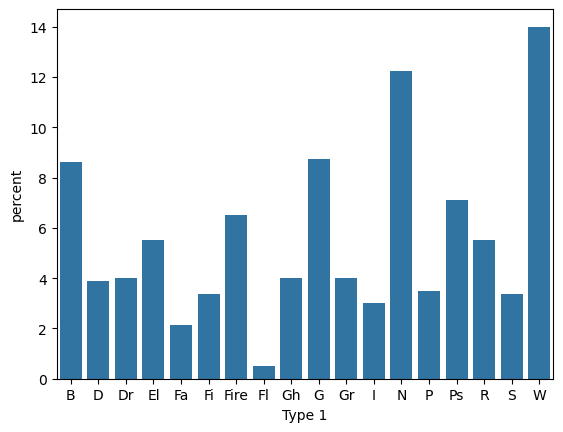

In [317]:
pl = sns.countplot(data=df, x = 'Type 1', stat = 'percent', order = ['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting', 'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice', 'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water'])
pl.set_xticks(range(18))
pl.set_xticklabels(['B', 'D', 'Dr', 'El', 'Fa', 'Fi', 'Fire', 'Fl', 'Gh', 'G', 'Gr', 'I', 'N', 'P', 'Ps', 'R', 'S', 'W'])

Draw conclusions from the plot. (Are there a lot of differnet types? What is the most/least popular type? ...)

**Answer** There are 18 different types of Pokemons. By far the least popular is the Flying (Fl in the plot) type of Pokemons, and most popular are Water (W in the plot) and Normal (N in the plot) types, which is consistent with the table given above. Flying, then, is a rare type. However, since Dragon type is not that rare, and at least some of the Dragons probably can fly, so it may be that the Flying type is what is rare and not the ability to fly itself. It is in accordance with the description of the dataset on Kaggle, where it is stated that "Some pokemon are dual type and have 2", so for Dragons it might be that the Dragon is their first type and Flying is the second. This will be interesting to investigate in spare time.

# Task 4 (2 points)

Compue the measures of central tendency for the `Sp. Atk` feature

In [322]:
col = df['Sp. Atk']
col.mean(), col.median(), col.mode()

(72.82,
 65.0,
 0    60
 Name: Sp. Atk, dtype: int64)

Draw a histogram for the feature and depict the measures on it

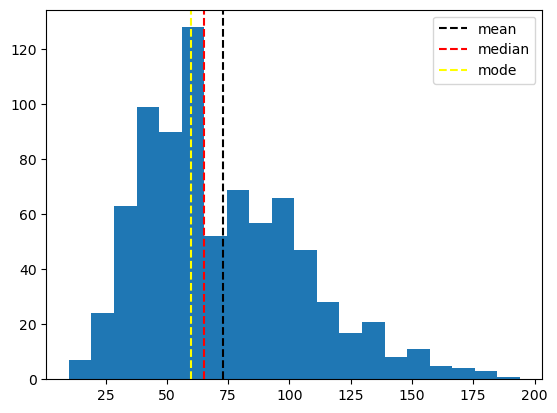

In [324]:
plt.hist(col, bins=20)

plt.axvline(col.mean(), linestyle='--', c='black', label='mean')
plt.axvline(col.median(), linestyle='--', c='red', label='median')
plt.axvline(col.mode()[0], linestyle='--', c='yellow', label='mode')

plt.legend(loc='upper right')
plt.show()

Is the distribution skewed? Explain your answer.

**Answer** The distribution is skewed to the left. We see that most of the values are approximately below the second quartile, the mean is quite far from the mode and median, and mean is shifted to the right of the median, which implies skewness of the distribution to the left.

# Task 5 (2 point)

Now, compute measures of central tendencies for legendary and not legendary separately. Is there any difference?

In [329]:
df.groupby('Legendary')['Sp. Atk'].mean() , df.groupby('Legendary')['Sp. Atk'].median(), df[df['Legendary'] == False]['Sp. Atk'].mode(), df[df['Legendary'] == True]['Sp. Atk'].mode()

(Legendary
 False     68.454422
 True     122.184615
 Name: Sp. Atk, dtype: float64,
 Legendary
 False     65.0
 True     120.0
 Name: Sp. Atk, dtype: float64,
 0    60
 Name: Sp. Atk, dtype: int64,
 0    150
 Name: Sp. Atk, dtype: int64)

**Answer** There is a big difference. The mean of distribution of Non-legendary Pokemons is 68.454422, while for Legendary it is 122.184615. Same can be said about the median (65.0 for Non-Legendary and and 120.0 for Legendary) and mode (60 for Non-legendary and 150 for Legendary). However, the separate distributions of special attack damage is more normally distributed for Non-legendary (68.454422 mean, 65.0 median, and 60 mode, which is a smaller of difference than what we have seen for the general distribution of special attack damage) and more symmetrically, but not normally for Legendary (122.184615 mean vs 120.0 median; mode is significantly different from the mean and median, being 150, but that does not imply skewness). What skewed the general distribution intially was the presence of both Legendary and Non-Legendary Pokemons together, while they have very different power of special attacks.

Draw the hisograms on one plot.

Hint: use `hue` in `sns.histplot`

<Axes: xlabel='Sp. Atk', ylabel='Count'>

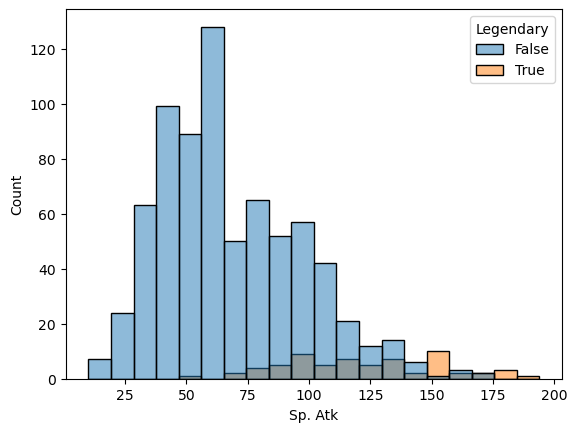

In [332]:
sns.histplot(data=df, x='Sp. Atk', bins=20, hue='Legendary')

# Task 6 (2 point)

There is a problem that bars for legendary pokemons are significantly smaller than the bars for non-legendary. Explain, why is it happening

<Axes: xlabel='Legendary', ylabel='count'>

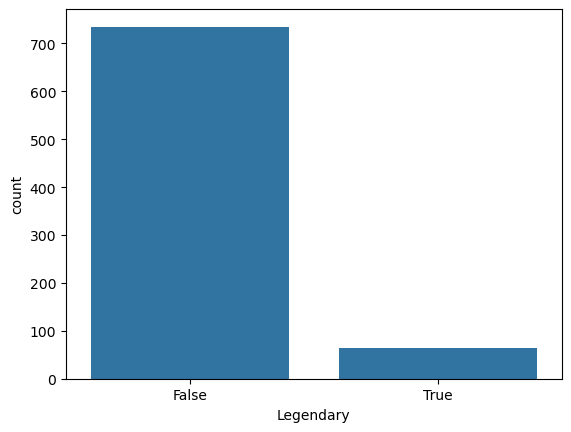

In [335]:
sns.countplot(data = df, x = 'Legendary')

**Answer** The bars represent numbers of observations for Pokemons with damage of special attack falling into some of the interval bin. Since Legendary Pokemons are much more rare than the Non-legendary (which is logical, since they are legendary), the amount of them in general will be significantly smaller, as is seen from the countplot. This makes the histogram with number of observations harder to read, and a more readable would be a histogram with distribution of special attack damage for Legendary and Non-legendary Pokemons measured in percentage from the whole amounts of observations of Legendary and Non-legendary Pokemons separately.

Fix the histogram (make the bars comparable hights), so it wil be more convenient to compare the distributions.

Hint: consult the [documentation for the histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) and find, which optional arguments may help.

<Axes: xlabel='Sp. Atk', ylabel='Percent'>

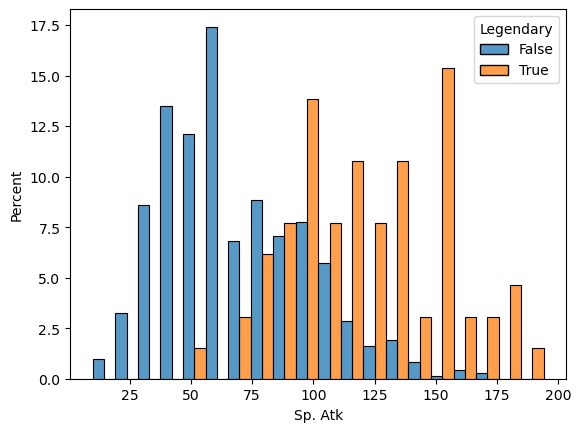

In [338]:
sns.histplot(data=df, x='Sp. Atk', bins=20, hue='Legendary', multiple = 'dodge', stat = 'percent', common_norm = False)

Now, make conclusions about the distributions

**Answer** From the fixed graph we may now draw more comprehensive conclusions about the distributions of special attack damage for Legendary and Non-legendary Pokemons separately. We can see that the distribution of special attack damage for Non-legendary Pokemons is less skewed, and for the Legendary Pokemons the distribution even resembles a symmetrical distribution, although not precisely, since there is a visible mode at around 155, while a high bar at 100 does not contain a mode as such, even though it is significantly higher compared to other bars besides the one at around 155. The mode around 155 is a bit inconsistent with the calculations we have made in the previous task (where it was 150), but this is ok since "binning" conducted in creating the plot may be the cause of this slight shift.
From the plot we conclude that the most frequent special attack damage for Non-legendary Pokemons is around 60, with general special attack damage being smaller compared to the Legendary Pokemons. Legendary Pokemons are stronger in terms of special attack, with their approximate mean and median being significantly higher that that for the Non-legendary. Separate graphs for distributions show how wrong was it to look at them together, since the distributions lie in very different ranges (from around 10 to 170 for Non-Legendary, and from around 55 to around 190 for Legendary ones, athought is it hard to state precisely based upon the graph solely).